# **1: Data Pre-Processing**

## **1.1** DEPENDENCIES INSTALLATION

In [1]:
!pip install wfdb
!pip install PyWavelets
!pip install mne
!pip install pykalman
!pip install numpy scipy matplotlib pywt pyemd opencv-python
!pip install PyEMD==1.0.0
!pip install tensorflow-addons==0.22.0
!pip install keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 35.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 15.2 MB/s eta 0:00:00
ERROR: Could not find a ver

In [2]:
import os
import re
import cv2
import wfdb
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import (
    butter, filtfilt, medfilt, savgol_filter, find_peaks, iirnotch,
    resample, lfilter, spectrogram, hilbert
)
from scipy.ndimage import gaussian_filter1d
from scipy.fft import fft, ifft
from scipy.fftpack import dct
from scipy.interpolate import interp1d, CubicSpline, BarycentricInterpolator
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA, FastICA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from pykalman import KalmanFilter
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.colab.patches import cv2_imshow


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **1.2** DATA PRE-PROCESSING (NOISE REMOVAL)

In [ ]:
lowcut = 0.5
highcut = 50.0
sampling_rate = 1000

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

def process_ecg_files(file_list, sampling_rate, lowcut, highcut):
    all_filtered_signals = pd.DataFrame()

    for file_path in file_list:
        try:
            data = pd.read_csv(file_path)

            for column in data.columns:
                ecg_signal = data[column].values
                filtered_signal = apply_bandpass_filter(ecg_signal, lowcut, highcut, sampling_rate)
                all_filtered_signals[f"{os.path.basename(file_path)}_{column}_filtered"] = filtered_signal

            print(f"Processed file: {file_path}")
        except Exception as e:
            print(f"Error processing file {file_path}: {str(e)}")

    return all_filtered_signals

# List of ECG files to process
file_list = [
    '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/EXTRACTED DATA PTB/Myocardial infarction/ii_df.csv'
]

# Process files and apply bandpass filter
filtered_ecg_signals_df = process_ecg_files(file_list, sampling_rate, lowcut, highcut)

# Save filtered signals to CSV
output_file = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv'
filtered_ecg_signals_df.to_csv(output_file, index=False)
print(f"Filtered signals saved to {output_file}")

Processed file: /content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/EXTRACTED DATA PTB/Myocardial infarction/ii_df.csv
Filtered signals saved to /content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv


## **1.3** DATA PRE-PROCESSING (DATA SEGMENTATION)

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

def pan_tompkins_qrs_detection(ecg_signal, sampling_rate):
    # Step 1: Differentiation
    diff_ecg = np.diff(ecg_signal)

    # Step 2: Squaring
    squared_ecg = diff_ecg ** 2

    # Step 3: Moving average integration
    window_size = int(0.15 * sampling_rate)  # 150 ms window
    integrated_ecg = np.convolve(squared_ecg, np.ones(window_size) / window_size, mode='same')

    # Step 4: Thresholding
    threshold = np.percentile(integrated_ecg, 95)  # Adjust percentile as needed

    # Step 5: Peak detection
    r_peaks, _ = find_peaks(integrated_ecg, height=threshold, distance=int(sampling_rate * 0.6))

    return r_peaks, integrated_ecg

def segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size):
    half_window = int(window_size * sampling_rate / 2)
    segments = []

    for r_peak in r_peaks:
        start = max(0, r_peak - half_window)
        end = min(len(ecg_signal), r_peak + half_window)
        segment = ecg_signal[start:end]

        # Pad the segment if it is shorter than the window size
        if len(segment) < 2 * half_window:
            segment = np.pad(segment, (0, max(0, 2 * half_window - len(segment))), mode='constant')

        segments.append(segment)

    return segments

def process_ecg_segmentation(input_csv, output_csv, sampling_rate=1000, window_size=5):
    ecg_data = pd.read_csv(input_csv)
    all_segments = []

    # Iterate over PATIENTS (columns)
    for patient_col in ecg_data.columns:  # Each column = patient
        ecg_signal = ecg_data[patient_col].dropna().values
        r_peaks, _ = pan_tompkins_qrs_detection(ecg_signal, sampling_rate)

        # Segment ECG for this patient
        segments = segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size)

        # Store segments with patient ID
        for seg in segments:
            all_segments.append({
                "patient_id": patient_col,
                "ecg_segment": seg.tolist()  # Store as list for DataFrame
            })

    # Create DataFrame with patient-segment mapping
    segments_df = pd.DataFrame(all_segments)
    segments_df.to_csv(output_csv, index=False)

if __name__ == "__main__":
    input_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv'
    output_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/segmentation_MI.csv'

    process_ecg_segmentation(input_csv, output_csv)

In [ ]:
# import os
# import numpy as np
# import pandas as pd
# from scipy.signal import find_peaks

# def pan_tompkins_qrs_detection(ecg_signal, sampling_rate):
#     # Step 1: Differentiation
#     diff_ecg = np.diff(ecg_signal)

#     # Step 2: Squaring
#     squared_ecg = diff_ecg ** 2

#     # Step 3: Moving average integration
#     window_size = int(0.15 * sampling_rate)  # 150 ms window
#     integrated_ecg = np.convolve(squared_ecg, np.ones(window_size) / window_size, mode='same')

#     # Step 4: Thresholding
#     threshold = np.percentile(integrated_ecg, 95)  # Adjust percentile as needed

#     # Step 5: Peak detection
#     r_peaks, _ = find_peaks(integrated_ecg, height=threshold, distance=int(sampling_rate * 0.6))

#     return r_peaks, integrated_ecg

# def segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size):
#     half_window = int(window_size * sampling_rate / 2)
#     segments = []

#     for r_peak in r_peaks:
#         start = max(0, r_peak - half_window)
#         end = min(len(ecg_signal), r_peak + half_window)
#         segment = ecg_signal[start:end]

#         # Pad the segment if it is shorter than the window size
#         if len(segment) < 2 * half_window:
#             segment = np.pad(segment, (0, max(0, 2 * half_window - len(segment))), mode='constant')

#         segments.append(segment)

#     return segments

# def process_ecg_segmentation(input_csv, output_csv, sampling_rate=1000, window_size=5):
#     os.makedirs(os.path.dirname(output_csv), exist_ok=True)

#     ecg_data = pd.read_csv(input_csv)

#     all_segments = []

#     for column in ecg_data.columns:
#         print(f"Processing patient: {column}")

#         ecg_signal = ecg_data[column].dropna().values

#         try:
#             r_peaks, _ = pan_tompkins_qrs_detection(ecg_signal, sampling_rate)

#             if len(r_peaks) == 0:
#                 print(f"No peaks detected for {column}. Skipping...")
#                 continue

#             segments = segment_ecg(ecg_signal, r_peaks, sampling_rate, window_size)

#             segments_df = pd.DataFrame(segments)
#             segments_df['patient_id'] = column
#             all_segments.append(segments_df)

#             print(f"Segmented ECG data for {column} processed.")

#         except Exception as e:
#             print(f"Error processing {column}: {e}")

#     combined_segments_df = pd.concat(all_segments, axis=0, ignore_index=True)

#     combined_segments_df.to_csv(output_csv, index=False)

#     print(f"All segmented ECG data saved to: {output_csv}")

# if __name__ == "__main__":
#     input_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/noise_reduction_MI.csv'
#     output_csv = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/segmentation_MI.csv'

#     process_ecg_segmentation(input_csv, output_csv)

Processing patient: ii_df.csv_patient_291_s0554_re_filtered
Segmented ECG data for ii_df.csv_patient_291_s0554_re_filtered processed.
Processing patient: ii_df.csv_patient_290_s0553_re_filtered
Segmented ECG data for ii_df.csv_patient_290_s0553_re_filtered processed.
Processing patient: ii_df.csv_patient_292_s0555_re_filtered
Segmented ECG data for ii_df.csv_patient_292_s0555_re_filtered processed.
Processing patient: ii_df.csv_patient_292_s0556_re_filtered
Segmented ECG data for ii_df.csv_patient_292_s0556_re_filtered processed.
Processing patient: ii_df.csv_patient_293_s0557_re_filtered
Segmented ECG data for ii_df.csv_patient_293_s0557_re_filtered processed.
Processing patient: ii_df.csv_patient_293_s0558_re_filtered
Segmented ECG data for ii_df.csv_patient_293_s0558_re_filtered processed.
Processing patient: ii_df.csv_patient_294_s0559_re_filtered
Segmented ECG data for ii_df.csv_patient_294_s0559_re_filtered processed.
Processing patient: ii_df.csv_patient_287_s0547_re_filtered
Se

## **1.4** DATA PRE-PROCESSING (UPSAMPLING)

In [ ]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
import ast
from tqdm import tqdm
import warnings

def safe_list_parser(data_str):
    """Robust string-to-list conversion with multiple format support"""
    try:
        return ast.literal_eval(data_str)
    except (ValueError, SyntaxError):
        # Handle numpy-style arrays
        cleaned = data_str.strip('[]').replace('\n', '').split(',')
        return [float(x.strip()) for x in cleaned if x.strip()]

def validate_rates(original_rate, target_rate):
    """Ensure valid sampling rate parameters"""
    if not (isinstance(original_rate, (int, float)) and isinstance(target_rate, (int, float))):
        raise TypeError("Sampling rates must be numeric")
    if original_rate <= 0 or target_rate <= 0:
        raise ValueError("Sampling rates must be positive")
    if target_rate <= original_rate:
        raise ValueError("Target rate must be greater than original rate")
    return target_rate / original_rate  # Return upsampling factor

def upsample_ecg_segment(original_signal, original_rate, target_rate):
    """Robust upsampling with proper time alignment"""
    # Input validation
    if len(original_signal) < 4:
        raise ValueError(f"Segment needs ≥4 points (got {len(original_signal)})")
    if any(np.isnan(original_signal)):
        raise ValueError("NaN values detected in input signal")

    # Calculate exact time vectors
    n_original = len(original_signal)
    original_time = np.arange(n_original) / original_rate
    duration = original_time[-1]  # Exact end time of original signal

    # Calculate upsampling parameters
    upsampling_factor = target_rate / original_rate
    n_upsampled = int(np.round(n_original * upsampling_factor))

    # Create interpolation grid
    upsampled_time = np.linspace(0, duration, n_upsampled)

    # Cubic spline interpolation
    cs = CubicSpline(original_time, original_signal, extrapolate=False)
    upsampled_signal = cs(upsampled_time)

    return upsampled_signal.tolist()

def process_ecg_data(input_csv, output_csv, original_rate=250, target_rate=1000):
    """Main processing pipeline with enhanced validation"""
    # Validate rates first
    try:
        upsampling_factor = validate_rates(original_rate, target_rate)
    except ValueError as e:
        print(f"Rate validation failed: {e}")
        return

    # Load data with format checks
    try:
        df = pd.read_csv(input_csv)
        if df.empty:
            raise ValueError("Input CSV is empty")
        if not {'patient_id', 'ecg_segment'}.issubset(df.columns):
            raise ValueError("Missing required columns")
    except Exception as e:
        print(f"Data loading error: {e}")
        return

    # Processing statistics
    stats = {
        'total': 0,
        'success': 0,
        'empty': 0,
        'short': 0,
        'invalid': 0,
        'nans': 0
    }

    processed_data = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing ECG segments"):
        stats['total'] += 1
        try:
            # Convert ECG segment
            ecg_str = row['ecg_segment']
            if not isinstance(ecg_str, str) or len(ecg_str) < 3:
                stats['invalid'] += 1
                continue

            original_signal = safe_list_parser(ecg_str)

            # Check signal validity
            if len(original_signal) == 0:
                stats['empty'] += 1
                continue
            if any(np.isnan(original_signal)):
                stats['nans'] += 1
                continue

            # Upsample and store
            upsampled = upsample_ecg_segment(
                original_signal=original_signal,
                original_rate=original_rate,
                target_rate=target_rate
            )

            processed_data.append({
                'patient_id': row['patient_id'],
                'ecg_segment': upsampled
            })
            stats['success'] += 1

        except ValueError as e:
            if "Segment needs ≥4 points" in str(e):
                stats['short'] += 1
            else:
                stats['invalid'] += 1
        except Exception as e:
            stats['invalid'] += 1
            warnings.warn(f"Row {_} failed: {str(e)}")

    # Save results and report statistics
    result_df = pd.DataFrame(processed_data)
    result_df.to_csv(output_csv, index=False)

    print(f"\nProcessing complete:")
    print(f" - Total segments: {stats['total']}")
    print(f" - Successfully processed: {stats['success']} ({stats['success']/stats['total']:.1%})")
    print(f" - Failed segments:")
    print(f"   • Empty: {stats['empty']}")
    print(f"   • Too short: {stats['short']}")
    print(f"   • NaNs: {stats['nans']}")
    print(f"   • Invalid format: {stats['invalid']}")
    print(f"Output saved to: {output_csv}")

# Configuration
input_path = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/CSV/SEGMENTATION CSV/segmentation_CAD.csv'
output_path = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/CSV/UPSAMPLING CSV/upsampling_CAD.csv'

# Execute processing
process_ecg_data(
    input_csv=input_path,
    output_csv=output_path,
    original_rate=250,
    target_rate=1000
)

## **1.5** IMAGE GENEARATION

In [ ]:
IMG_SIZE = (128, 128)
OUTPUT_DIR = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images'

def normalize_and_resize(image):
    if image.ndim == 1:
        image = np.tile(image, (IMG_SIZE[0], 1))  # Convert 1D to 2D by tiling
    normalized_image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    resized_image = cv2.resize(normalized_image.astype(np.uint8), IMG_SIZE)
    return resized_image

# 1. Time-Frequency Representation (TFR) using STFT
def time_frequency_representation(ecg_signal, fs=250):
    f, t, Sxx = spectrogram(ecg_signal, fs)
    Sxx = np.where(Sxx == 0, np.finfo(float).eps, Sxx)  # Avoid log(0)
    Sxx = 10 * np.log10(Sxx)
    return normalize_and_resize(Sxx)

# 2. Fourier Transform (FT)
def fourier_transform_image(ecg_signal):
    ft = fft(ecg_signal)
    ft_magnitude = np.abs(ft[:len(ft)//2])
    # Create a 2D array by repeating the 1D signal vertically
    ft_2d = np.tile(ft_magnitude, (IMG_SIZE[0], 1))
    return normalize_and_resize(ft_2d)

# 3. Gramian Angular Field (GAF)
def gaf_image(ecg_signal):
    min_val, max_val = np.min(ecg_signal), np.max(ecg_signal)
    if max_val == min_val:
        scaled_signal = np.zeros_like(ecg_signal)
    else:
        scaled_signal = 2 * (ecg_signal - min_val) / (max_val - min_val) - 1  # Scale to [-1, 1]
    scaled_signal = np.clip(scaled_signal, -1, 1)  # Ensure within [-1, 1]
    phi = np.arccos(scaled_signal)
    gaf = np.cos(np.add.outer(phi, phi))
    return normalize_and_resize(gaf)

# 4. Markov Transition Field (MTF)
def mtf_image(ecg_signal, bins=128):
    hist, bin_edges = np.histogram(ecg_signal, bins=bins)
    # Use full bin_edges for digitization
    signal_digitized = np.digitize(ecg_signal, bin_edges) - 1  # Convert to 0-based
    signal_digitized = np.clip(signal_digitized, 0, bins-1)  # Ensure within valid range
    mtf = np.zeros((bins, bins))
    for i in range(1, len(signal_digitized)):
        prev_bin = signal_digitized[i-1]
        curr_bin = signal_digitized[i]
        mtf[prev_bin, curr_bin] += 1
    mtf += 1e-10  # Avoid division by zero
    mtf /= mtf.sum()
    return normalize_and_resize(mtf)

# 5. Recurrence Quantification Analysis (RQA)
def rqa_image(ecg_signal, m=3, tau=1, threshold=0.1):
    # Phase space reconstruction with embedding dimension m and time lag tau
    n = len(ecg_signal) - (m-1)*tau
    if n <= 0:
        return np.zeros((IMG_SIZE[0], IMG_SIZE[1]))
    embedded = np.zeros((n, m))
    for i in range(m):
        embedded[:, i] = ecg_signal[i*tau : i*tau + n]
    # Compute recurrence matrix
    rqa_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            distance = np.linalg.norm(embedded[i] - embedded[j])
            rqa_matrix[i, j] = 1 if distance < threshold else 0
    return normalize_and_resize(rqa_matrix)

import ast
INPUT_CSV = '/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/segmentation_MI.csv'
output_folder_name = "MI"  # folder name

def generate_images():
    data = pd.read_csv(INPUT_CSV)  # Load segmentation CSV

    # Iterate over ROWS (each row = ECG segment)
    # for idx, row in data.iloc[100:].iterrows():
    for idx, row in data[1336:].iterrows():
        # Convert string-list to numerical array
        ecg_signal = np.array(ast.literal_eval(row["ecg_segment"]))
        patient_id = row["patient_id"]

        # Ensure segment has 5000 points (pad/truncate if needed)
        if len(ecg_signal) != 5000:
            print(f"This is an error... {len(ecg_signal)}" )
            ecg_signal = np.pad(ecg_signal, (0, max(0, 5001 - len(ecg_signal))), mode='constant')[:5001]

        # Generate 5 images per segment
        transformations = {
            "TFR": time_frequency_representation(ecg_signal),
            "FT": fourier_transform_image(ecg_signal),
            "GAF": gaf_image(ecg_signal),
            "MTF": mtf_image(ecg_signal),
            "RQA": rqa_image(ecg_signal)
        }
        # Save with patient-segment identifier
        for transform_name, img in transformations.items():
            output_path = f"{OUTPUT_DIR}/{patient_id}_seg{idx}_{transform_name}.png"
            print(output_path)
            cv2.imwrite(output_path, img)

generate_images()

# for file_path in file_list:
#     data = pd.read_csv(file_path)

#     file_name = os.path.basename(file_path).split('.')[0]
#     file_output_dir = os.path.join(OUTPUT_DIR, file_name, output_folder_name)
#     os.makedirs(file_output_dir, exist_ok=True)

#     for patient_index, column in enumerate(data.columns, start=1):
#         ecg_signal = data[column].dropna().values

#         transformations = {
#             "TFR": time_frequency_representation(ecg_signal),
#             "FT": fourier_transform_image(ecg_signal),
#             "GAF": gaf_image(ecg_signal),
#             "MTF": mtf_image(ecg_signal),
#             "RQA": rqa_image(ecg_signal)
#         }

#         for transform_index, (transform_name, image) in enumerate(transformations.items(), start=1):
#             output_path = os.path.join(file_output_dir, f"{patient_index}_{transform_index}.png")
#             cv2.imwrite(output_path, image)
#             print(f"Saved {output_path}")


/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_TFR.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_FT.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_GAF.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_MTF.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1336_RQA.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1337_TFR.png
/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images/ii_df.csv_patient_293_s0557_re.1_filtered_seg1337_FT.png
/content/drive/MyDrive/DISEASE CLASS

# **2: Feature Engineering, Model Development & Optimization**

## FUSION MODEL

In [ ]:
import os
import re
import cv2
import numpy as np
from collections import defaultdict

def fuse_images(image_list):
    """Fuses a list of images by averaging their pixel values."""
    sum_img = np.zeros_like(image_list[0], dtype=np.float32)
    for img in image_list:
        sum_img += img.astype(np.float32)
    avg_img = sum_img / len(image_list)
    return np.clip(avg_img, 0, 255).astype(np.uint8)

def group_images(folder_path):
    """Groups images by patient and segment using regex parsing."""
    groups = defaultdict(list)
    pattern = re.compile(r'patient_(\d+).*_seg(\d+)_([A-Z]{2,4})\.')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            match = pattern.search(filename)
            if match:
                patient = match.group(1)
                segment = match.group(2)
                img_type = match.group(3)
                groups[(patient, segment)].append((img_type, filename))
    return groups

def main(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    groups = group_images(input_folder)
    required_types = {'FT', 'GAF', 'MTF', 'RQA', 'TFR'}

    for (patient, segment), images in groups.items():
        # Check for exactly 5 images
        if len(images) != 5:
            print(f"Skipping {patient}-{segment}: Has {len(images)} images")
            continue

        # Verify all required image types are present
        present_types = {img[0] for img in images}
        if present_types != required_types:
            print(f"Skipping {patient}-{segment}: Missing types {required_types - present_types}")
            continue

        # Load images in consistent order
        images.sort()  # Sorts by image type alphabetically
        img_data = []
        for img_type, filename in images:
            img_path = os.path.join(input_folder, filename)
            img = cv2.imread(img_path)
            if img is not None:
                img_data.append(img)
            else:
                print(f"Failed to load: {img_path}")
                break

        if len(img_data) == 5:
            fused_img = fuse_images(img_data)
            output_path = os.path.join(output_folder, f"fused_{patient}_{segment}.jpg")
            cv2.imwrite(output_path, fused_img)
            print(f"Created fusion for {patient}-{segment}")

# Example usage
input_folder = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/TEST/CSV/Images"
output_folder = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Images/MI_FUSED_IMAGES"
main(input_folder, output_folder)

Created fusion for 291-1194
Created fusion for 291-1195
Created fusion for 291-1196
Created fusion for 291-1197
Created fusion for 291-1198
Created fusion for 291-1199
Created fusion for 291-1200
Created fusion for 291-1201
Created fusion for 291-1202
Created fusion for 291-1203
Created fusion for 291-1204
Created fusion for 291-1205
Created fusion for 291-1206
Created fusion for 291-1207
Created fusion for 291-1208
Created fusion for 291-1209
Created fusion for 291-1210
Created fusion for 291-1211
Created fusion for 291-1212
Created fusion for 291-1213
Created fusion for 291-1214
Created fusion for 291-1215
Created fusion for 291-1216
Created fusion for 291-1217
Created fusion for 291-1218
Created fusion for 291-1219
Created fusion for 291-1220
Created fusion for 291-1221
Created fusion for 291-1222
Created fusion for 291-1223
Created fusion for 291-1224
Created fusion for 291-1225
Created fusion for 291-1226
Created fusion for 291-1227
Created fusion for 291-1228
Created fusion for 2

## **2.0** FEATURE ENGINEERING (FEATURES SELECTION | FEATURES GENERATION)

## **2.1** IMAGE LOADING

In [6]:
# def load_image_paths_and_labels(folder1, folder2, validate_images=False):
#     """Load image paths and labels from two class directories with enhanced validation.

#     Args:
#         folder1: Path to directory containing class 0 images
#         folder2: Path to directory containing class 1 images
#         validate_images: Whether to verify images can be opened (slower)

#     Returns:
#         Tuple of (image_paths, labels)
#     """
#     image_paths = []
#     labels = []
#     skipped_files = defaultdict(int)
#     class_folders = {0: folder1, 1: folder2}

#     for class_label, folder in class_folders.items():
#         if not os.path.exists(folder):
#             raise ValueError(f"Directory {folder} for class {class_label} does not exist")

#         # Get sorted list of files for reproducibility
#         try:
#             files = sorted(os.listdir(folder))
#         except PermissionError:
#             raise RuntimeError(f"Permission denied accessing {folder}")

#         for filename in files:
#             file_path = os.path.join(folder, filename)

#             # Skip directories and hidden files
#             if not os.path.isfile(file_path) or filename.startswith('.'):
#                 skipped_files['non_files'] += 1
#                 continue

#             # Validate image extension
#             if not filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
#                 skipped_files['invalid_ext'] += 1
#                 continue

#             # Optional image validation
#             if validate_images:
#                 try:
#                     img = cv2.imread(file_path)
#                     if img is None:
#                         raise ValueError("Invalid image file")
#                     # Basic image dimension check
#                     if img.size == 0:
#                         raise ValueError("Empty image")
#                 except Exception as e:
#                     skipped_files['invalid_image'] += 1
#                     print(f"Skipping invalid image: {file_path} ({str(e)})")
#                     continue

#             image_paths.append(file_path)
#             labels.append(class_label)

#     # Validation checks
#     if not image_paths:
#         raise RuntimeError("No valid images found in either directory")

#     if len(image_paths) != len(labels):
#         raise RuntimeError("Critical error: Path/label count mismatch")

#     # Detailed class report
#     class_counts = np.bincount(labels)
#     print("Image loading report:")
#     print(f"- Total images loaded: {len(image_paths)}")
#     print(f"- Class distribution: {dict(enumerate(class_counts))}")
#     print(f"- Skipped items: {dict(skipped_files)}")

#     return image_paths, labels


# folder_paths = [
#     "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Images/HC_FUSED_IMAGES",  # Replace with your actual path for class 1
#     "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Images/MI_FUSED_IMAGES"   # Replace with your actual path for class 2
# ]

# # Load images and labels
# image_paths, labels = load_image_paths_and_labels(folder_paths[0], folder_paths[1])

## **2.2** MODEL TRAINING (SELECTED MODEL)

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.applications import ResNet50  # Changed to ResNet50
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

# ---------------------------
# Configuration
# ---------------------------
folder1_path = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Images/CAD_FUSED_IMAGES"  # Class 0
folder2_path = "/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Images/HC_FUSED_IMAGES"  # Class 1

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 10

# ---------------------------
# Enhanced Data Loading with Class Distribution Analysis
# ---------------------------
def load_data_with_analysis(folder1, folder2):
    class0_files = [f for f in os.listdir(folder1) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class1_files = [f for f in os.listdir(folder2) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"Class 0 samples: {len(class0_files)}")
    print(f"Class 1 samples: {len(class1_files)}")
    print(f"Total samples: {len(class0_files) + len(class1_files)}")
    print(f"Class ratio: {len(class0_files)/len(class1_files):.2f}:1")

    paths = []
    labels = []
    for f in class0_files:
        paths.append(os.path.join(folder1, f))
        labels.append(0)
    for f in class1_files:
        paths.append(os.path.join(folder2, f))
        labels.append(1)

    return paths, labels

paths, labels = load_data_with_analysis(folder1_path, folder2_path)

# ---------------------------
# Stratified Train-Test Split
# ---------------------------
train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths, labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED
)

train_labels_ = np.array(train_labels)
test_labels_ = np.array(test_labels)

print("\nTraining set class distribution:")
print(f"- Class 0: {sum(train_labels_ == 0)}")
print(f"- Class 1: {sum(train_labels_ == 1)}")

print("\nTest set class distribution:")
print(f"- Class 0: {sum(test_labels_ == 0)}")
print(f"- Class 1: {sum(test_labels_ == 1)}")

# ---------------------------
# Class Weight Calculation
# ---------------------------
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weights}")

# ---------------------------
# Optimized Data Pipeline
# ---------------------------
def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

def create_dataset(paths, labels, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if is_training:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True, seed=SEED)
        ds = ds.map(lambda path, label: (tf.io.read_file(path), label),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda content, label: (tf.image.decode_image(content, channels=3, expand_animations=False), label),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda image, label: (tf.image.random_flip_left_right(image, seed=SEED), label),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda image, label: (tf.image.random_brightness(image, 0.2, seed=SEED), label),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda image, label: (tf.image.random_contrast(image, 0.7, 1.3, seed=SEED), label),
                    num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda path, label: (tf.io.read_file(path), label),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(lambda content, label: (tf.image.decode_image(content, channels=3, expand_animations=False), label),
                    num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_paths, train_labels, is_training=True)
test_ds = create_dataset(test_paths, test_labels)

# ---------------------------
# Improved Model Architecture (ResNet50)
# ---------------------------
def build_model():
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    for layer in base_model.layers[:100]:
        layer.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base_model(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_model()
model.summary()

# ---------------------------
# Enhanced Training with Callbacks
# ---------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=10,
    verbose=1,
    mode='max',
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)


Class 0 samples: 1278
Class 1 samples: 1172
Total samples: 2450
Class ratio: 1.09:1

Training set class distribution:
- Class 0: 1022
- Class 1: 938

Test set class distribution:
- Class 0: 256
- Class 1: 234

Class weights: {0: np.float64(0.958904109589041), 1: np.float64(1.044776119402985)}
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 19,977,729 (76.21 MB)

 Non-trainable params: 4,134,784 (15.77 MB)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 337s 5s/step - accuracy: 0.9133 - auc: 0.9620 - loss: 0.1853 - precision: 0.9017 - recall: 0.9107 - val_accuracy: 0.9694 - val_auc: 0.9980 - val_loss: 0.0720 - val_precision: 0.9398 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.9993 - auc: 1.0000 - loss: 0.0064 - precision: 0.9993 - recall: 0.9993 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0016 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step - accuracy: 0.9986 - auc: 1.0000 - loss: 0.0064 - precision: 1.0000 - recall: 0.9971 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 4.4646e-04 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 15s 240ms/step - accuracy: 0.9954 - auc: 1.0000 - loss: 0.0077 - precision: 0.9919 - recall: 0.9986 - val_accuracy: 0.9980 - val_auc: 1.0000 - val_

In [8]:
model.save("/content/drive/MyDrive/DISEASE CLASSIFICATION BY ECG [FYP CODE]/Binary Classification Training/MI_HC_model.h5")
print(f"\nFinal model saved\n")


Final model saved



## **2.3** MODEL EVALUATION (ON TEST DATA)

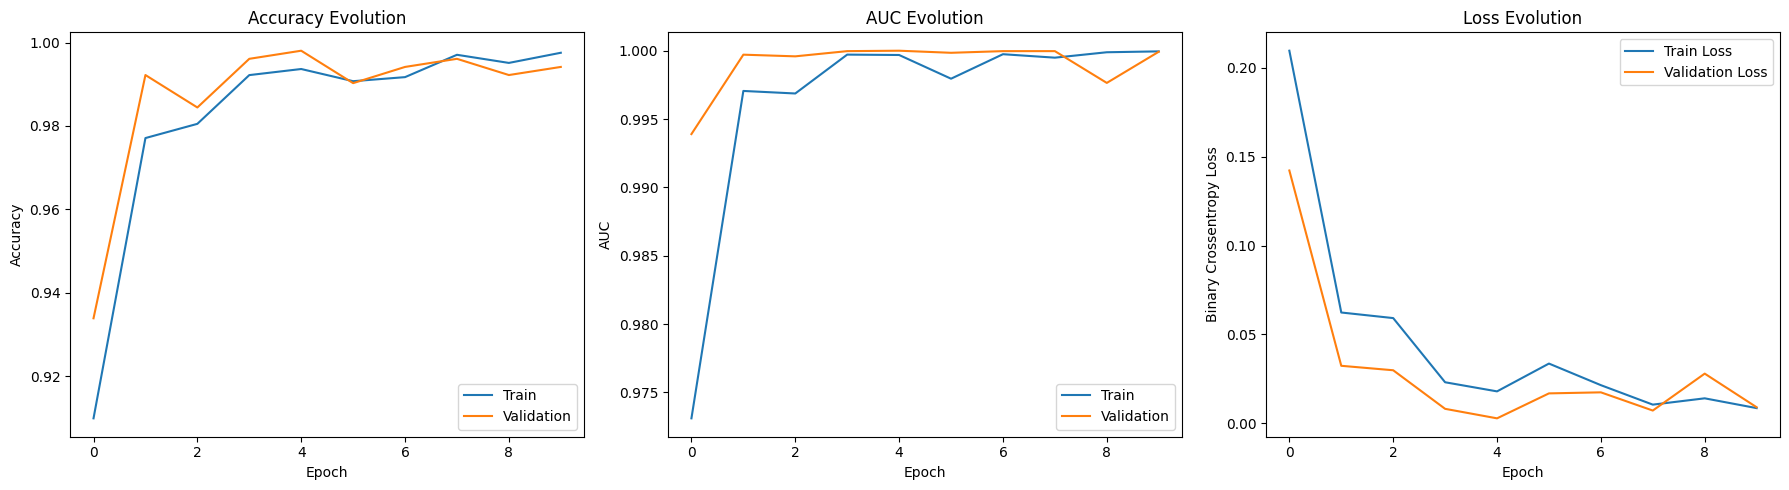


Final Training Accuracy: 99.76%
Final Validation Accuracy: 99.42%
Final Validation AUC: 0.9999

Final Test Evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.9986 - auc: 1.0000 - loss: 0.0022 - precision: 1.0000 - recall: 0.9970
Test Accuracy: 99.81%
Test AUC: 1.0000


In [9]:

# ---------------------------
# Comprehensive Evaluation
# ---------------------------
def analyze_results(history):
    plt.figure(figsize=(18, 5))

    # Accuracy plot
    plt.subplot(1, 3, 1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title('Accuracy Evolution')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()

    # AUC plot
    plt.subplot(1, 3, 2)
    plt.plot(history.history['auc'], label='Train')
    plt.plot(history.history['val_auc'], label='Validation')
    plt.title('AUC Evolution')
    plt.ylabel('AUC')
    plt.xlabel('Epoch')
    plt.legend()

    # Loss plot
    plt.subplot(1, 3, 3)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Evolution')
    plt.ylabel('Binary Crossentropy Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    final_val_auc = history.history['val_auc'][-1]
    print(f"\nFinal Training Accuracy: {final_train_acc:.2%}")
    print(f"Final Validation Accuracy: {final_val_acc:.2%}")
    print(f"Final Validation AUC: {final_val_auc:.4f}")

analyze_results(history)

# ---------------------------
# Test Set Evaluation
# ---------------------------
print("\nFinal Test Evaluation:")
test_results = model.evaluate(test_ds)
print(f"Test Accuracy: {test_results[1]:.2%}")
print(f"Test AUC: {test_results[2]:.4f}")


# **3: Model Performance Assessment**

## **3.1** EVALUATION

## **3.2** FINAL RESULTS